# INNM_Ptycho —— 把 INNM 的前向模型从 FPM 换成 ptychography

与 `INNM_FPM.ipynb` 共用 `functions/innm_common.py`（评估指标、正则项、`safe_angle`、亚像素平移、自定义层）。本文件只负责前向物理模型。

## FPM ↔ ptychography

两者计算图同构，实空间与频域的角色对调：

| | FPM | Ptychography |
|---|---|---|
| `Or/Oi` 权重 | 物体**频谱** O(k) | 物体**实空间**复透射率 O(r) |
| 平移的对象 | 频谱，位移 = LED 角度 | 物体，位移 = 扫描位置 |
| 与照明相乘 | × 光瞳 P(k)，频域局域 | × 探针 P(r)，实空间局域 |
| 到测量面 | ifft → 低分辨图 | fft → ×H(δz) → ifft（角谱） |
| `out1/out2` 取物体 | 需先 ifft(Or+iOi) | 权重本身就是物体，**不做变换** |

出射波按 KACP 式(1) `ψ_j = P(r)·O(r − r_j)`，传播按式(10)~(12) 的角谱方法
`U = IFFT[FFT(ψ)·H]`，其中 `H = exp(i·√(k²−fx²−fy²)·δz)`。

## 自检（已验证）

| 项 | 结果 |
|---|---|
| 角谱往返（传播→反传） | 相对误差 5.5e-8 |
| TF 前向 vs numpy 前向（同一探针） | 相对误差 5.7e-7 |
| 整数位置：`crop_patch_np` == 直接切片 | 逐位相同（0.0） |
| 物体梯度的回流窗口 | 恰好 128×128，完整落在 224 画布内 |
| 旧写法（整幅相位斜坡）在同一 patch 上的偏差 | 6.1e-2，见下 |

**旧写法的 6.1e-2 是真实误差，不是数值噪声。** 相位斜坡的插值核是全局的
（sinc），画布本身又不周期，所以边界不连续引起的 Gibbs 振铃会散布到整幅图上，
而不只是边缘。裁剪没有这个问题 —— 这就是换掉它的主要理由。

**已知的一处不一致（与本次改动无关，改之前就有）**：仿真用的是完整真值探针
`probe`，模型里是 `probe × support`，支撑域外还剩 0.5% 能量，所以「真值代入后
数据残差」约 **5e-2** 而不是接近 0。要么把仿真也乘上 support（那是 inverse crime），
要么承认这就是模型的表示下限。目前保持后者，但报告残差时要知道有这个底。

纯 L_mse 基线（224 画布、25 点、8 stage）：物体 SSIM 0.783 / PSNR 25.60 dB /
复场误差 0.120 / 探针复场误差 0.093。**旧的 128 画布基线数字全部作废**，
物体尺寸、评估区位置、边界条件都变了，不可比。

## 几个关键选择及其依据

**探针 = 自由复数矩阵**（`Pr` 实部 + `Pi` 虚部两张可训练图），不做基底展开，没有别的选项。
Zernike 参数化（样品面、光瞳面两种）都已删除：样品面版本实测差一倍（物体 SSIM 0.381
vs 0.748）；光瞳面版本只有 z 正确时才赢，z 错 30% 时反而更差（0.4635 vs 0.7009）。
真值探针是圆孔传播出来的菲涅耳环带，10 个 Zernike 模式对它的拟合残差 1.09 rad RMS
（相位动态范围才 6.15 rad）；真实探针还有散斑与高频粗糙度，低阶基底原理上拟合不了。
实验结论见 `doc/README_zernike_probe.md`，代码封存在 `doc/attic/zernike_probe_ptycho.py`。

**扫描路径不能用规则光栅**（raster grid pathology, Thibault et al. 2009）。实测 8 stage：

| 扫描 | 物体 SSIM | 物体 PSNR | 位置谱峰均比 |
|---|---|---|---|
| `raster` | 0.5461 | 17.85 | 36.1 |
| `raster_jitter`（默认） | 0.7791 | 20.96 | 22.2 |
| `fermat` | 0.8154 | 15.14 | 8.4 |

fermat 覆盖圆形区域而评估裁方形，所以 PSNR 吃亏；ROI 是圆形时应选它。
另注**重叠率有两种定义**，文献的 60%~80% 多指面积重叠（本配置线性 70.6% / 面积 63.1%）。

**物体寻址 = 局部裁剪（crop patch）**，这是 AD ptychography 的主流做法
（tike / PtyRAD / ptychodus）。物体画布 `N_OBJ=224` 比探测器 `N=128` 大，
每个位置从画布上裁一块 128×128 出来。相位斜坡的老写法已删除，它把整幅物体
当成周期的（循环边界互相污染），而且 FFT 成本随画布增长。

小数位置仍用相位斜坡，但只作用在裁出的 patch 上 —— patch 边缘那 1px 的循环误差
落在探针支撑域外（支撑半径 25px，离 patch 边 39px），被探针的零值吃掉。
纯取整会引入最多 0.5 px 误差，实测让 SSIM 从 0.909 掉到 0.731，所以不能省。

**位置仍然可微**：整数部分经 `floor` 梯度为 0，小数部分完全可微 ——
position refinement 只要把 corner 变成可训练量即可。

**探针初值**用针孔场传播到样品面（估计距离，非真值）。换成平圆盘的话第一个 stage
从 SSIM 0.47 掉到 0.13，等于白跑约 5 个 stage。

**数据项固定为 `‖|U| − √I‖²`**（参考实现 Seifert et al. 的写法），没有别的选项。
原 INNM 的 Gerchberg–Saxton 幅值替换分支**已删除**：二者数学恒等 ——
`ψ−ψ' = IFFT[FFT(U−U')·conj(H)]`，`|H|=1` 使传播酉、范数不变，
而 `U−U' = e^{i·angle(U)}·(|U|−√I)`，故 `‖ψ−ψ'‖ = ‖|U|−√I‖`；
实测 L2 范数 28.99655161 vs 28.99655164、重建逐位相同，而 GS 多算一对 FFT。
（顺带一提：这说明 GS 幅值替换在 AD 框架里不提供任何额外信息，只是换了个写法。）

## 五个必读注意事项

1. **扫描位置是浮点像素**。相位斜坡靠广播生成，所以 `batch_size` 不再被限制为 1
   （默认仍用 1，以保持已调好的收敛行为）。
2. **`support` 必须是二值的**。模型里有 `Pr × support`，软边孔径会被平方一次。
3. **学习率与 FPM 差 4 个数量级**。FPM 的权重是频谱（1e4）故 `lr=200`；
   这里是实空间透射率（~1），`lr` 用 3e-2。
4. **`Pi` 层存的是探针虚部图**。`Pr`/`Pi` 都要乘 `support` 才是真正的探针，用 `get_probe()` 读。
5. **正则权重要看它与数据项的比例，不是绝对数值**。Keras 的 `loss='mse'` 是元素均值，
   所以正则也该用 `reduce='mean'`，两者才天然同量级；用 `reduce='sum'` 会差约 1.6e4 倍。

## 两个区域的区别（容易看混）

两者都是从 **224×224 画布** 每边裁掉的像素数：

- `EVAL_CROP = 64` → 中心 96×96，**算指标**用（与旧版 128−2×16 的评估区同尺寸）
- `REG_CROP = 48` → 中心 128×128，正则项作用的区域，约等于照明区

换成大画布之后，**没有数据约束的区域从约 13% 涨到约 66%**（照明区只有中心
约 130px）。所以 `REG_CROP=0` 现在是危险的默认值：无下界的正则（比如原始 `-K` 峰度）
会把尖峰全堆到那片死区 —— 全图显示被色标拉黑，而中心 96×96 的 PSNR 照样很高。
这种情况要看 `Rmax` 而不是 PSNR。默认给到 48 就是为了把正则关在照明区里。

In [57]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"     # 纯 CPU 改成 "-1"

import importlib.util
if importlib.util.find_spec("tf_keras") is not None:
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
else:
    os.environ.pop("TF_USE_LEGACY_KERAS", None)

import numpy as np
import cv2
import tensorflow as tf
from pathlib import Path
import sys
from math import pi
%matplotlib inline
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Lambda

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'simulations':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from functions.project_paths import project_path
from functions import innm_common as ic
# innm_common.py 是普通 .py，Python 会把它缓存在 sys.modules 里 ——
# 改了这个文件之后重跑 import 是【没用】的，会报 "has no attribute xxx"。
# 这行强制重新读盘，省掉每次都要 Restart Kernel。
importlib.reload(ic)
ic.silence_known_tf_warnings()

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
try:
    _kv = tf.keras.__version__
except AttributeError:
    import keras as _k; _kv = _k.__version__
print("TensorFlow:", tf.__version__, "| tf.keras:", _kv, "| GPU:", gpus)
assert _kv.startswith("2."), f"需要 Keras 2.x，当前 {_kv}"

TensorFlow: 2.15.1 | tf.keras: 2.15.0 | GPU: []


In [58]:
# ===================== 参数 =====================
wlength   = 632.8e-9      # 波长（HeNe，与 KACP 实验一致）
N         = 128           # 探测器 / patch 边长（前向模型的计算网格）
N_OBJ     = 224           # 物体画布边长。crop patch 要求画布 > patch：
                          #   N_OBJ >= N + 扫描跨度 + 抖动余量
                          #   当前 5x5 x step20 + 20% 抖动 -> 跨度 88 -> 需要 >= 216
dx        = 10e-6         # 样品/探测器面像素尺寸
k0        = 2*pi/wlength

probe_dia = 48            # 探针直径（像素）
dz_true   = 8e-3          # 真实样品-探测器距离
# 评估区与正则区：都是从 N_OBJ 画布每边裁掉的像素数。
# 画布只有中心约 130px 被照明，外面完全没有数据约束，所以两者都不能设 0。
EVAL_SIZE = 96                          # 评估正方形边长（与旧版 128-2*16 同尺寸）
EVAL_CROP = (N_OBJ - EVAL_SIZE)//2      # = 64
REG_CROP  = (N_OBJ - 128)//2            # = 48，正则只作用在中心 128（约等于照明区）

# --- 探针 ---
# 探针是【自由复数矩阵】：实部/虚部各一张可训练二维图，不做任何基底展开。
# 这是标准 ptychography 的做法 —— 探针可能来自针孔、波带片或聚焦光束，
# 强加低阶 Zernike 之类的先验会严重限制表示能力（实测物体 SSIM 0.38 vs 0.75）。
z_probe = 3e-3            # 孔径到样品的距离，用于合成真值探针（菲涅耳环带）

# --- 探针初值 ---
# 'propagated' 用针孔场传播到样品面作为初值（参考实现 Seifert et al. 的做法）。
#              注意用的是【估计的】传播距离，不是真值，不构成作弊。
# 'flat'       平的二值圆盘、零相位 —— 物理上不可能的场，收敛明显更慢。
# 实测（96 epoch）：flat -> 物体SSIM 0.856 / 探针误差 0.064
#                  propagated -> 物体SSIM 0.912 / 探针误差 0.038
PROBE_INIT   = 'propagated'
z_probe_init = 3e-3*1.3   # 故意与真值 z_probe 差 30%，模拟"只知道大概"

# --- 探针模型 ---
# 自由复数矩阵，唯一选项：实部/虚部各一张可训练二维图。
# 名义上 2N^2，但 support 掩膜外恒为 0，有效未知量 = 2 * support 内像素数 = 3922。
# support 只是稳定性约束（限定探针的空间范围），不限制探针形状。
#
# 【Zernike 参数化已删除】12 个系数能把探针误差降到 1/2.6，但只有传播距离 z 正确
# 时才赢：z 错 30% 时物体 SSIM 0.4635，比自由探针的 0.7009 还差。深近场
# （菲涅耳数 R^2/(lambda*z)=17）下离焦只能吸收 2% 的 z 误差，用它就必须先做自动对焦。
# 结论见 doc/README_zernike_probe.md，代码封存在 doc/attic/zernike_probe_ptycho.py。
R_AP = probe_dia/2 - 6          # 真值孔径半径（像素）

# --- 真值探针的像差 ---
# 真值探针 = 孔径场传播到样品面。PROBE_ABERR > 0 时先在孔径上加一层平滑随机相位，
# 让真值不是一个理想圆孔 —— 低剂量/低重叠实验里需要这个非理想性。
#
# 【实测灵敏度】菲涅耳数 17 是深近场，孔径上一点相位就把样品面的环带整个重排：
#     PROBE_ABERR   样品面探针变化   衍射图变化
#       0.05           17.1%          15.3%
#       0.1            33.3%          29.4%
#       0.2            60.9%          51.4%
#       0.5          101.6%          76.8%     <- 已经是"换了个探针"，重建掉到 SSIM<0.1
# 0.5 rad RMS 听起来只有 lambda/12，实测却是灾难。
# 【这张表已作废，要用请重测】它是用旧的 Zernike 基底像差测的。换成平滑随机相位
# （高斯模糊 sigma=1.5）之后，同样 0.1 rad RMS 只造成 10.0% 的探针变化，
# 而不是 33.3% —— 基底里的离焦/球差在深近场传播得凶得多。同一个 rad RMS
# 在不同像差谱下完全不是一回事，报这个数时必须说清楚像差是怎么生成的。
PROBE_ABERR = 0.0     # 孔径面像差强度（rad RMS）；0 = 理想圆孔
ABERR_SEED  = 7

# --- 优化方式 ---
# 'joint'       物体与探针同时更新（标准 ADP ptychography，参考实现的做法）
# 'alternating' INNM 的 OBJ/PRB 交替 —— 那是 FPM 的结构
# 实测（96 epoch、物理探针初值）各有胜负：
#   交替  lr=3e-2  -> SSIM 0.912  PSNR 23.67  探针误差 0.0377
#   联合  lr=3e-3  -> SSIM 0.821  PSNR 26.26  探针误差 0.0328
# 联合的 PSNR 与探针恢复更好，交替的 SSIM 更好。联合对学习率敏感得多
# （lr=3e-2 直接崩到 SSIM 0.12），这也是 INNM 用交替的原因之一。
OPT_MODE = 'alternating'

# --- 扫描方案 ---
# ptychography 的扫描路径【不能用规则光栅】。规则光栅会产生 raster grid pathology
# （Thibault et al. 2009）：位置的周期性与物体/探针的周期性简并，重建出周期性伪影。
# 标准做法是给光栅加随机抖动，或者干脆用 Fermat 螺旋（Huang et al. 2014，重叠最均匀）。
SCAN_PATTERN = 'raster_jitter'   # 'raster' / 'raster_jitter' / 'fermat'
SCAN_NPOS    = 25                # 扫描点数 36/16
SCAN_STEP    = 20                # 标称步长（像素）
SCAN_JITTER  = 0.2               # 抖动幅度，占步长的比例
SCAN_SEED    = 0

# 角谱方法的采样上限：|dz| <= N*dx^2/lambda，超过会混叠
dz_max = N*dx**2/wlength
print(f'角谱采样上限 dz_max = {dz_max*1e3:.2f} mm  当前 dz = {dz_true*1e3:.2f} mm '
      f'-> {"OK" if abs(dz_true) <= dz_max else "超限！会混叠"}')

角谱采样上限 dz_max = 20.23 mm  当前 dz = 8.00 mm -> OK


In [59]:
# ===================== 角谱传递函数 =====================
def make_H(dz, N=N, dx=dx, k0=k0, wlength=wlength, band_limit=True):
    """KACP 式(10): H(fx,fy,dz) = exp(i*sqrt(k^2 - fx^2 - fy^2) * dz)

    直接用 fftfreq 建在【未 shift 的 FFT 排布】上，与 tf.signal.fft3d 的输出对齐，
    整条链路不需要任何 fftshift / roll —— 比 FPM 那套 roll 来 roll 去干净得多。

    倏逝波区（arg<0）必须写成衰减 exp(-|kz|·|dz|)，写成增长会数值爆炸。
    band_limit 是 Matsushima 带限，抑制大 dz 时的混叠。
    """
    f = 2*pi*np.fft.fftfreq(N, d=dx)          # rad/m，已是 FFT 顺序
    FX, FY = np.meshgrid(f, f, indexing='ij')
    arg = k0**2 - FX**2 - FY**2
    kz = np.sqrt(np.abs(arg))
    H = np.where(arg >= 0, np.exp(1j*kz*dz), np.exp(-kz*abs(dz)))
    if band_limit and dz != 0:
        f_lim = 2*pi/(wlength*np.sqrt((2*abs(dz)/(N*dx))**2 + 1))
        H = np.where(FX**2 + FY**2 <= f_lim**2, H, 0)
    return H.astype(np.complex64)


def propagate_np(field, dz):
    """numpy 角谱传播，用于仿真与 KACP 峰度搜索"""
    return np.fft.ifft2(np.fft.fft2(field)*make_H(dz))


H_true = make_H(dz_true)
# 自检：传播 -> 反传应当回到原场
_t = np.random.default_rng(0).random((N, N)) + 1j*np.random.default_rng(1).random((N, N))
_b = np.fft.ifft2(np.fft.fft2(propagate_np(_t, dz_true))*np.conj(H_true))
print(f'角谱往返相对误差: {np.linalg.norm(_b-_t)/np.linalg.norm(_t):.3e}  (应 ~1e-8)')

角谱往返相对误差: 5.461e-08  (应 ~1e-8)


In [60]:
# ===================== 真值物体、探针、扫描网格 =====================
# 物体：cameraman 当幅值（透射率 0.4~1.0），westconcord 当相位
# 【画布尺寸】物体建在 N_OBJ 画布上，不是 N —— crop patch 要求画布大于 patch。
_a = cv2.resize(cv2.imread(str(project_path('cameraman.bmp')), 0), (N_OBJ, N_OBJ), interpolation=cv2.INTER_CUBIC).astype(float)
_a = 0.4 + 0.6*_a/_a.max()
_p = cv2.resize(cv2.imread(str(project_path('westconcordorthophoto.bmp')), 0), (N_OBJ, N_OBJ), interpolation=cv2.INTER_CUBIC).astype(float)
_p = cv2.normalize(_p, None, -1, 1.0, cv2.NORM_MINMAX)
obj = (_a*np.exp(1j*0.8*_p)).astype(np.complex64)      # 真值物体（实空间复透射率）

yy, xx = np.mgrid[0:N, 0:N] - N/2
rr = np.sqrt(xx**2 + yy**2)


# ---------- 真值探针 ----------
# 圆孔传播一段距离 -> 菲涅耳环带，接近真实针孔探针。
# 这种结构无法用低阶基底描述（实测 10 个 Zernike 模式的拟合残差高达 1.09 rad RMS，
# 而相位动态范围才 6.15 rad），所以模型必须用自由复数矩阵。
# 真值光瞳 = 二值圆孔（+ 可选的平滑随机像差）
pupil_mask = (rr <= R_AP)
if PROBE_ABERR > 0:
    _r = cv2.GaussianBlur(np.random.default_rng(ABERR_SEED)
                          .normal(size=(N, N)).astype(np.float64), (0, 0), 1.5)
    _phi_ap = _r*(PROBE_ABERR/np.sqrt(np.mean(_r[pupil_mask]**2)))
else:
    _phi_ap = np.zeros((N, N))
pupil_true = (pupil_mask*np.exp(1j*_phi_ap)).astype(np.complex64)
probe = propagate_np(pupil_true, z_probe)
probe = (probe/np.abs(probe).max()).astype(np.complex64)
print(f'真值光瞳: 半径 {R_AP:.0f}px  孔径面像差 {PROBE_ABERR:.3f} rad RMS'
      + ('   <- 0，理想圆孔，与加这段之前逐位相同' if PROBE_ABERR == 0 else ''))

# 支撑域掩膜：二值，取到包住 99.5% 能量为止。
# 必须二值 —— 模型里有 Pr * support，带软边的话振幅会被平方一次。
for _R in range(int(probe_dia/2), N//2):
    if (np.abs(probe)**2*(rr <= _R)).sum()/(np.abs(probe)**2).sum() > 0.995:
        break
support = (rr <= _R).astype(np.float32)
print(f'真值探针: 圆孔传播 {z_probe*1e3:.1f} mm  支撑半径 {_R} px'
      f'  (含能量 {(np.abs(probe)**2*(rr <= _R)).sum()/(np.abs(probe)**2).sum():.4f})')

# ---------- 扫描路径 ----------
def overlap_areal(d, D):
    """两个直径 D 的圆盘、中心距 d 时的【面积重叠率】。

    注意与【线性重叠率】1-d/D 的区别：ptychography 文献里 "60%~80% 重叠"
    多数指面积重叠。同一个几何下两者能差 8 个百分点
    （d=16, D=48 时线性 66.7%，面积只有 58.4%），报错了会得出相反结论。
    """
    R = D/2.0
    if d >= 2*R: return 0.0
    if d <= 0:   return 1.0
    a = 2*R**2*np.arccos(d/(2*R)) - (d/2)*np.sqrt(max(4*R**2-d**2, 0))
    return float(a/(np.pi*R**2))


def make_scan_positions(pattern=SCAN_PATTERN, n_pos=SCAN_NPOS, step=SCAN_STEP,
                        jitter_frac=SCAN_JITTER, seed=SCAN_SEED, radius=None):
    """生成扫描位置（浮点像素 —— 模型用傅里叶相位斜坡做亚像素平移）。

    raster        —— 规则光栅。仅用于复现/对照，实际不要用（见下方实测）。
    raster_jitter —— 光栅 + 均匀随机抖动，破坏周期性。推荐默认。
    fermat        —— Fermat 螺旋 r=c*sqrt(n), theta=n*137.508deg，重叠最均匀。
    """
    rng = np.random.default_rng(seed)
    if pattern in ('raster', 'raster_jitter'):
        k = int(round(np.sqrt(n_pos))); off = (k-1)*step/2
        p = np.array([[i*step-off, j*step-off] for i in range(k) for j in range(k)], float)
        if pattern == 'raster_jitter':
            p += rng.uniform(-jitter_frac*step, jitter_frac*step, p.shape)
    elif pattern == 'fermat':
        R = radius if radius else step*np.sqrt(n_pos)/2
        n = np.arange(1, n_pos+1)
        r = (R/np.sqrt(n_pos))*np.sqrt(n)
        th = n*np.deg2rad(137.508)
        p = np.stack([r*np.cos(th), r*np.sin(th)], 1)
    else:
        raise ValueError(f'未知扫描方案: {pattern}')
    # 【不再取整】——裁剪只吃整数部分，小数部分交给 patch 上的相位斜坡。
    # 纯取整会引入平均 0.235 px 的位置误差，实测让 SSIM 从 0.909 掉到 0.731。
    return p.astype(np.float32)


def scan_report(P, D=probe_dia):
    """报告扫描路径的关键统计量"""
    P = np.asarray(P, float)
    dd = np.sqrt(((P[:, None, :]-P[None, :, :])**2).sum(-1)) + np.eye(len(P))*1e9
    nn = dd.min(1)
    ov = np.array([overlap_areal(d, D) for d in nn])
    g = np.zeros((N, N))
    for x, y in P:
        g[int(round(x)) % N, int(round(y)) % N] += 1
    F = np.abs(np.fft.fft2(g))**2; F[0, 0] = 0
    print(f'  点数 {len(P)}  覆盖范围 {tuple(P.max(0)-P.min(0))} px')
    print(f'  最近邻距离 中位数 {np.median(nn):.1f} px')
    print(f'  线性重叠 {1-np.median(nn)/D:.1%}   面积重叠 {np.median(ov):.1%} '
          f'(标准差 {ov.std():.3f})   <- 文献的 60%~80% 多指面积重叠')
    print(f'  位置谱 峰值/均值 {F.max()/F.mean():.1f}   <- 越大周期性越强，越易出栅格伪影')


# patch 左上角 = PATCH_C0 - position，与旧的"整幅物体平移 position"逐点等价：
# 两种写法下 patch 中心看到的都是物体的 (画布中心 - position) 处。
PATCH_C0 = (N_OBJ - N)/2.0          # position=0 时裁的就是画布正中央的 128x128
SCAN_LIMIT = PATCH_C0               # |position| 的上限，超了 patch 就越出画布


def check_scan_fits(P):
    m = float(np.abs(np.asarray(P)).max())
    assert m <= SCAN_LIMIT, (
        f'扫描位置最大 |{m:.1f}| px 超过画布余量 {SCAN_LIMIT:.1f} px。\n'
        f'把 N_OBJ 提到 >= {int(np.ceil(N + 2*m))}，或者调小 SCAN_STEP / SCAN_NPOS。')
    return m


positions = make_scan_positions()
batchsize = len(positions)
_mx = check_scan_fits(positions)
print(f'物体画布 {obj.shape}  patch {N}x{N}  探针直径 {probe_dia}px  扫描方案 {SCAN_PATTERN}')
print(f'  位置极值 {_mx:.1f} px / 余量 {SCAN_LIMIT:.1f} px   照明区约 {2*_mx+2*probe_dia/2:.0f} px'
      f'   评估区 {EVAL_SIZE}x{EVAL_SIZE}  正则区 {N_OBJ-2*REG_CROP}x{N_OBJ-2*REG_CROP}')
scan_report(positions)
_re = np.abs(positions - np.rint(positions))
print(f'  位置小数部分 平均 {_re.mean():.3f} px  最大 {_re.max():.3f} px'
      f'  <- 裁剪吃整数部分，小数部分由 patch 上的相位斜坡处理')

# 【实测对照】8 stage、纯 L_mse、其余参数相同：
#   方案            物体SSIM   物体PSNR   复场误差   探针相位RMS   位置谱峰均比
#   raster           0.5461     17.85     0.2254      0.3071        36.1
#   raster_jitter    0.7791     20.96     0.2170      0.3030        22.2
#   fermat           0.8154     15.14     0.2709      0.2372         8.4
#
# 规则光栅比抖动光栅差 43%（SSIM），栅格伪影是真实存在的。
# fermat 的 SSIM 与探针恢复最好，但它覆盖的是圆形区域，
# 而评估裁的是方形，所以 PSNR/复场误差反而吃亏 —— 若你的 ROI 是圆形则应选 fermat。
# 默认用 raster_jitter：方形覆盖、四项指标里三项最优、改动最小。

真值探针: 圆孔传播 3.0 mm  支撑半径 25 px  (含能量 0.9963)
物体 (128, 128)  探针直径 48px  扫描方案 raster_jitter
  点数 25  覆盖范围 (84.42660903930664, 87.45867156982422) px
  最近邻距离 中位数 17.9 px
  线性重叠 62.7%   面积重叠 53.6% (标准差 0.049)   <- 文献的 60%~80% 多指面积重叠
  位置谱 峰值/均值 16.7   <- 越大周期性越强，越易出栅格伪影
  位置小数部分 平均 0.241 px  最大 0.494 px  <- 用傅里叶斜坡平移，不取整


In [61]:
# ===================== 仿真衍射图 =====================
# --- 噪声开关 ---
ADD_POISSON_NOISE   = False
PEAK_PHOTONS        = 5000
NOISE_GLOBAL_NORM   = True    # True = 物理正确：所有图共用一个光子标度
NOISE_SEED          = 42
_rng = np.random.default_rng(NOISE_SEED)

# 【为什么必须 GLOBAL_NORM】实际实验中曝光时间和照明强度对所有扫描点是一样的，
# 弱信号的图本来就该暗得多。若每张图各自归一化到 PEAK_PHOTONS，
# 等于人为把弱信号图的信噪比拉高。在 FPM 里实测这个差异极大：
# 暗场图的零像素占比 0.42%(逐图归一化) vs 33.43%(全局归一化)。


def forward_np(O, P, pos, H):
    """KACP 式(1)+(12)：exit wave = P·O(r-rj)，再角谱传播到探测器面。
    物体寻址用局部裁剪（整数）+ patch 上的相位斜坡（小数），与模型内部完全一致。"""
    psi = ic.crop_patch_np(O, PATCH_C0 - np.asarray(pos, float), N)*P
    U = np.fft.ifft2(np.fft.fft2(psi)*H)
    return psi, U


input0 = np.ones((batchsize, N_OBJ, N_OBJ, 1), np.float32)     # 全1，用于提取权重（画布尺寸）
input1 = positions.reshape(batchsize, 2, 1, 1).astype(np.float32)  # 扫描位置（浮点像素）
input2 = np.empty((batchsize, N, N, 1), np.float32)             # 衍射强度

for i, p in enumerate(positions):
    _, U = forward_np(obj, probe, p, H_true)
    input2[i, :, :, 0] = np.abs(U)**2

if ADD_POISSON_NOISE:
    gmax = float(input2.max())
    for i in range(batchsize):
        I = input2[i, :, :, 0]
        imax = gmax if NOISE_GLOBAL_NORM else float(I.max())
        scale = PEAK_PHOTONS/(imax + 1e-12)
        input2[i, :, :, 0] = _rng.poisson(np.maximum(I, 0)*scale).astype(np.float32)/scale
    print(f'零像素占比: {100*(input2 == 0).mean():.2f}%')

print(f'衍射图 {input2.shape}  强度范围 [{input2.min():.3e}, {input2.max():.3e}]')
print(f'泊松噪声: {ADD_POISSON_NOISE}  峰值光子 {PEAK_PHOTONS}  全局归一化 {NOISE_GLOBAL_NORM}')

衍射图 (25, 128, 128, 1)  强度范围 [2.151e-10, 1.008e+00]
泊松噪声: False  峰值光子 5000  全局归一化 True


In [62]:
# ===================== 前向模型 =====================
def build_ptycho(train_obj, train_probe, H_const):
    """与 FPM 的 build_ORI 一一对应，两个 Trainable 开关控制交替优化。"""
    Hk  = tf.constant(H_const.reshape(1, N, N, 1))
    apk = tf.constant(support.reshape(1, N, N, 1))

    i_all1 = Input((N_OBJ, N_OBJ, 1), dtype='float32', name='input_all1')
    i_pos  = Input((2, 1, 1), dtype='float32', name='input_pos')   # 浮点像素

    # 物体：权重直接就是实空间复透射率（FPM 里存的是频谱，这是最大区别）。
    # 画布是 N_OBJ x N_OBJ，比 patch 大。
    Or = ic.MyLayer_OBJ((N_OBJ, N_OBJ, 1), name='Or', trainable=train_obj)(i_all1)
    Oi = ic.MyLayer_OBJ((N_OBJ, N_OBJ, 1), name='Oi', trainable=train_obj)(i_all1)
    Ofull = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j*tf.cast(x[1], tf.complex64),
                   name='object_full')([Or, Oi])
    # 局部裁剪：整数部分 gather，小数部分在 patch 上做相位斜坡。
    # 反向传播时 gather 的梯度是 scatter-add 回画布的那个窗口 ——
    # 相当于 ePIE 手写的"把更新贴回物体"，这里由 autodiff 自动完成。
    Osh = Lambda(lambda x: ic.crop_patch_tf(x[0], PATCH_C0 - x[1], N),
                 output_shape=(N, N, 1), name='O_patch')([Ofull, i_pos])

    # 探针 P(r)：自由复数矩阵，实部/虚部各一张可训练二维图。
    # 有效未知量 = 2 * support 内像素数 = 3922（掩膜外恒为 0，不算自由度）。
    Pre = ic.MyLayer_PUP((N, N, 1), name='Pr', trainable=train_probe)(i_all1)
    Pim = ic.MyLayer_PUP((N, N, 1), name='Pi', trainable=train_probe)(i_all1)
    Pre = Lambda(lambda x: x*apk, name='probe_real')(Pre)
    Pim = Lambda(lambda x: x*apk, name='probe_imag')(Pim)
    Pc = Lambda(lambda x: tf.cast(x[0], tf.complex64)+1j*tf.cast(x[1], tf.complex64),
                name='probe_complex')([Pre, Pim])

    # 出射波 psi = O_shifted × P（KACP 式1），两边都已是复数，直接相乘
    psi = Lambda(lambda x: x[0]*x[1], name='exit_wave')([Osh, Pc])

    # 角谱传播到探测器面
    U = Lambda(lambda x: tf.signal.ifft3d(tf.signal.fft3d(x)*Hk), name='detector_field')(psi)

    # 数据项：直接输出预测幅值 |U|，训练时与 sqrt(I_meas) 比（y[0] 见 Ptycho.train）。
    # 实测衍射图不再进模型，所以模型只有两个输入。
    # 原 INNM 的 GS 幅值替换分支已删除 —— 与此式数学恒等、结果逐位相同，只是多一对 FFT。
    out0 = Lambda(lambda x: tf.abs(x), name='data_fidelity')(U)
    # FPM 里这里要先 ifft 才拿到物体；ptychography 的权重本身就是物体，直接取
    Oc = Lambda(lambda x: tf.cast(x[0], tf.complex64)+1j*tf.cast(x[1], tf.complex64),
                name='object_complex')([Or, Oi])
    # data fidelity 仍使用完整探测器/出射波；只把物体正则限制到有效 ROI。
    if REG_CROP > 0:
        Oc_reg = Lambda(lambda x: x[:, REG_CROP:-REG_CROP, REG_CROP:-REG_CROP, :],
                        name='object_reg_roi')(Oc)
    else:
        Oc_reg = Oc
    out1 = Lambda(lambda x: tf.abs(x), name='TV_real')(Oc_reg)
    out2 = Lambda(lambda x: ic.safe_angle(x), name='TV_imag')(Oc_reg)
    return Model(inputs=[i_all1, i_pos], outputs=[out0, out1, out2])


def get_object(model):
    r = np.asarray(model.get_layer('Or').get_weights())[0, :, :, 0]
    i = np.asarray(model.get_layer('Oi').get_weights())[0, :, :, 0]
    return r + 1j*i           # 无需 ifft


def evaluate_object_roi(rec, gt, crop=EVAL_CROP):
    """先裁到有效 ROI，再在 ROI 内完成全局复数对齐和指标计算。"""
    if crop > 0:
        rec = rec[crop:-crop, crop:-crop]
        gt = gt[crop:-crop, crop:-crop]
    return ic.evaluate_object(rec, gt, crop=0)


def get_probe(model):
    """返回 (振幅, 相位)。"""
    re = np.asarray(model.get_layer('Pr').get_weights())[0, :, :, 0]*support
    im = np.asarray(model.get_layer('Pi').get_weights())[0, :, :, 0]*support
    P = re + 1j*im
    return np.abs(P), np.angle(P)*(support > 0)


# 交替优化时需要在两个模型之间同步的探针权重名
PROBE_LAYERS = ['Pr', 'Pi']

In [63]:
# ===================== 交替优化 =====================
class Ptycho():
    """结构与 INNM_FPM 的 FPM 类一一对应：两个共享权重的模型交替训练。"""

    def __init__(self, H_const=None):
        self.H = H_true if H_const is None else H_const
        if OPT_MODE == 'joint':
            self.OBJ = build_ptycho(True, True, self.H)   # 物体与探针同时可训练
            self.PRB = self.OBJ
        else:
            self.OBJ = build_ptycho(True, False, self.H)
            self.PRB = build_ptycho(False, True, self.H)

    def _sync(self, src, dst):
        if src is dst:
            return                       # joint 模式下两者是同一个模型
        for n in ['Or', 'Oi'] + PROBE_LAYERS:
            dst.get_layer(n).set_weights(src.get_layer(n).get_weights())

    def _init_weights(self):
        # ptychography 标准初始化：物体全 1；探针 = 已知孔径、零相位
        self.OBJ.get_layer('Or').set_weights([np.ones((N_OBJ, N_OBJ, 1), np.float32)])
        self.OBJ.get_layer('Oi').set_weights([np.zeros((N_OBJ, N_OBJ, 1), np.float32)])
        # 探针初值：针孔场传播到样品面（参考实现 Seifert et al. 的做法），
        # 用的是【估计的】传播距离 z_probe_init，不是真值。
        if PROBE_INIT == 'propagated':
            P0 = propagate_np((rr <= probe_dia/2 - 6).astype(np.complex64), z_probe_init)
            P0 = P0/np.abs(P0).max()*support
        else:
            P0 = support.astype(np.complex64)
        self.OBJ.get_layer('Pr').set_weights([np.real(P0).reshape(N, N, 1).astype(np.float32)])
        self.OBJ.get_layer('Pi').set_weights([np.imag(P0).reshape(N, N, 1).astype(np.float32)])

    def train(self, stages, tv1=0.0, tv2=0.0, reg_loss=None,
              lr_OBJ=3e-2, lr_PRB=None, decay=0.75,
              OBJ_epoch=8, PRB_epoch=8, verbose=1, on_stage_end=None,
              warmup_stages=0, data_loss='mse'):
        """lr 默认值与 FPM 差 4 个数量级 —— FPM 的权重是频谱(1e4)，这里是透射率(1)。

        decay=0.75 是实测调出来的（纯 L_mse，8 stage 对照）：
            decay=0.9   最佳 SSIM 0.4354 @stage7，之后回落（震荡）
            decay=0.75  最佳 SSIM 0.5461 @stage8，单调不回落
            decay=0.75 + lr 翻倍  SSIM 0.5133，反而变差
        延长到 14 stage 后 SSIM 0.5639 / PSNR 18.36dB / 复场误差 0.2111，仍在缓慢改善。
        """
        if reg_loss is None:
            reg_loss = ic.make_tv_loss()
        if lr_PRB is None:
            # 自由复数探针有 ~2*支撑域像素数 个自由度，与物体同量级，lr 也应同量级。
            # 实测（12 stage）：lr_PRB=3e-3 -> 物体SSIM 0.41 ；3e-2 -> 0.748 ；1e-1 -> 0.484
            lr_PRB = 3e-2
        self._init_weights()

        X = [input0, input1]
        reg_n = N_OBJ - 2*REG_CROP
        zz_reg = np.zeros((batchsize, reg_n, reg_n, 1), np.float32)
        # 数据项的目标就是实测幅值 sqrt(I)
        y0 = np.sqrt(np.maximum(input2, 0)).astype(np.float32)
        hist_obj, hist_prb = [], []
        rec_o = {k: [] for k in ['psnr_o_amp', 'psnr_o_phi', 'ssim_o_amp', 'ssim_o_phi',
                                 'rmse_o_phi_rad', 'relerr_o_complex']}
        rec_p = {k: [] for k in ['psnr_p_amp', 'psnr_p_phi', 'ssim_p_amp', 'ssim_p_phi',
                                 'rms_p_phi_rad', 'relerr_p_complex']}
        lo, lp = lr_OBJ, lr_PRB

        for st in range(stages):
            # warmup_stages: 前若干 stage 关掉正则，只用数据项。
            # 有些正则（例如打靶型 (K-K_target)^2）在初始化时就顶着最大惩罚，
            # 而那时物体是常数、统计量处在 0/0 区，梯度方向不可靠 —— 必须先热身。
            w1 = 0.0 if st < warmup_stages else tv1
            w2 = 0.0 if st < warmup_stages else tv2
            # data_loss 可换成泊松 NLL 等 —— out0 已经是 |U|，似然在损失内部平方即可，
            # 不需要动模型结构
            self.OBJ.compile(loss=[data_loss, reg_loss, reg_loss],
                             optimizer=Adam(learning_rate=lo, amsgrad=True),
                             loss_weights=[1, w1, w2])
            for _ in range(OBJ_epoch):
                h = self.OBJ.fit(X, [y0, zz_reg, zz_reg], batch_size=1, epochs=1,
                                 verbose=0, shuffle=False)
                hist_obj.append(h.history['loss'][0])
            lo *= decay
            self._sync(self.OBJ, self.PRB)

            if OPT_MODE != 'joint':          # joint 模式下探针已在上面一起更新了
                self.PRB.compile(loss=[data_loss, reg_loss, reg_loss],
                                 optimizer=Adam(learning_rate=lp, amsgrad=True),
                                 loss_weights=[1, 0, 0])
                for _ in range(PRB_epoch):
                    h = self.PRB.fit(X, [y0, zz_reg, zz_reg], batch_size=1, epochs=1,
                                     verbose=0, shuffle=False)
                    hist_prb.append(h.history['loss'][0])
                lp *= decay
                self._sync(self.PRB, self.OBJ)

            obj_now = get_object(self.OBJ)
            for k, v in evaluate_object_roi(obj_now, obj, crop=EVAL_CROP).items():
                rec_o[k].append(v)
            amp, phi = get_probe(self.OBJ)
            for k, v in ic.evaluate_probe(amp, phi, probe, support > 0).items():
                if k in rec_p:
                    rec_p[k].append(v)
            # 需要额外诊断量（比如峰度消融）时传 on_stage_end，
            # 签名 f(stage, self, rec_o, rec_p) -> str|None，返回的字符串会附在日志后面。
            extra = on_stage_end(st+1, self, rec_o, rec_p) if on_stage_end else None

            if verbose:
                msg = (f'  stage {st+1}/{stages} | amplitude PSNR '
                       f'{rec_o["psnr_o_amp"][-1]:6.2f} dB | '
                       f'SSIM {rec_o["ssim_o_amp"][-1]:.4f} | phase RMSE '
                       f'{rec_o["rmse_o_phi_rad"][-1]:.4f} rad | complex error '
                       f'{rec_o["relerr_o_complex"][-1]:.4f} | probe error '
                       f'{rec_p["relerr_p_complex"][-1]:.4f}')
                if extra:
                    msg += ' | ' + extra
                print(msg, flush=True)

        return rec_o, rec_p

In [65]:
pty = Ptycho()

In [66]:
# ===================== 训练 =====================
# 正则项从 innm_common 里取，与 INNM_FPM 完全一致：
#   ic.make_tv_loss()            各向同性 TV（原版等价）
#   ic.make_aniso_tv_loss()      各向异性 L1-TV
#   ic.make_tgv_loss(w1=1,w2=2)  TGV，治阶梯效应
#   ic.make_hessian_loss()       Hessian
# tv1 = 幅值正则权重, tv2 = 相位正则权重；都设 0 就是纯 L_mse

# === 基线：纯 L_mse（tv1=tv2=0，正则项完全不参与梯度）===
# 零权重与物理删掉正则分支的结果【逐位相同】，所以这就是干净的纯 mse 复现，
# 唯一代价是正则分支仍会前向计算一遍（约慢一倍）。
# record_obj, record_probe = pty.train(25, tv1=0.0, tv2=0.0)
# 预期结果（默认配置：自由复数探针 + 物理探针初值 + direct 损失 + raster_jitter 36点）：
#   stage  1: SSIM 0.472  PSNR 14.94dB  物体复场误差 0.272  探针复场误差 0.142
#   stage  6: SSIM 0.739  PSNR 20.79dB  物体复场误差 0.137  探针复场误差 0.077
#   stage 12: SSIM 0.892  PSNR 23.70dB  物体复场误差 0.116  探针复场误差 0.060
# 单调收敛，到 12 stage 仍在改善。对上这几个数就说明流程复现无误。
#
# 与"平探针初值"相比第一个 stage 就从 SSIM 0.128 提到 0.474 —— 好初值省掉约 5 个 stage。
#
# 三组对照（改一个开关即可复现）：
#   SCAN_PATTERN='raster'        -> 栅格伪影，物体 SSIM 掉到约 0.55
#   PROBE_INIT='flat'            -> 探针初值退化成平圆盘，第一个 stage 从 SSIM 0.47 掉到 0.13
#   OPT_MODE='joint'             -> 联合优化（需同时把 lr 降到 3e-3，否则发散）

# --- 消融：加 TGV 正则 ---
# 用 reduce='mean' 让正则项与数据项同量级（Keras 的 mse 也是均值）。
# 量级说明与自动定权重工具见下面的 "正则项权重怎么定" cell。
run_name = 'MSE + TGV'
record_obj, record_probe = pty.train(8, tv1=1e-2, tv2=0,
                                     reg_loss=ic.make_tgv_loss(w1=1.0, w2=2.0, reduce='mean'))

  stage 1/8 | amplitude PSNR  18.42 dB | SSIM 0.4836 | phase RMSE 0.2463 rad | complex error 0.2512 | probe error 0.1353
  stage 2/8 | amplitude PSNR  19.03 dB | SSIM 0.5198 | phase RMSE 0.1995 rad | complex error 0.2159 | probe error 0.1166
  stage 3/8 | amplitude PSNR  23.06 dB | SSIM 0.6450 | phase RMSE 0.1646 rad | complex error 0.1723 | probe error 0.0974
  stage 4/8 | amplitude PSNR  24.36 dB | SSIM 0.7085 | phase RMSE 0.1500 rad | complex error 0.1566 | probe error 0.0878
  stage 5/8 | amplitude PSNR  26.51 dB | SSIM 0.7866 | phase RMSE 0.1398 rad | complex error 0.1435 | probe error 0.0779
  stage 6/8 | amplitude PSNR  27.83 dB | SSIM 0.8393 | phase RMSE 0.1336 rad | complex error 0.1357 | probe error 0.0700
  stage 7/8 | amplitude PSNR  28.79 dB | SSIM 0.8753 | phase RMSE 0.1295 rad | complex error 0.1306 | probe error 0.0662
  stage 8/8 | amplitude PSNR  29.48 dB | SSIM 0.8990 | phase RMSE 0.1267 rad | complex error 0.1272 | probe error 0.0640


剂量 PEAK_PHOTONS=1000  平均 13.9 光子/px
  幅值相对误差 11.4%   零像素 68%   REG_CROP=16  stages=8  TGV beta=0.01

[1/3] 无噪声 无正则
[2/3] 有噪声 无正则
[3/3] 有噪声 TGV beta=0.01
(input2 已恢复无噪声)

配置                     复场误差     SSIM   PSNR(dB)       探针误差
----------------------------------------------------------------------
noisy-free no regularization     0.2170   0.5197      19.08     0.1257
noisy with no regularization     0.2382   0.4488      17.52     0.1209
TGV 0.01             0.1990   0.7095      22.27     0.1004

噪声的代价:  0.2170 -> 0.2382   (+0.0212)
TGV beta=0.01:  0.2382 -> 0.1990   (-0.0392)  -> 有帮助
  挽回了噪声代价的 185%


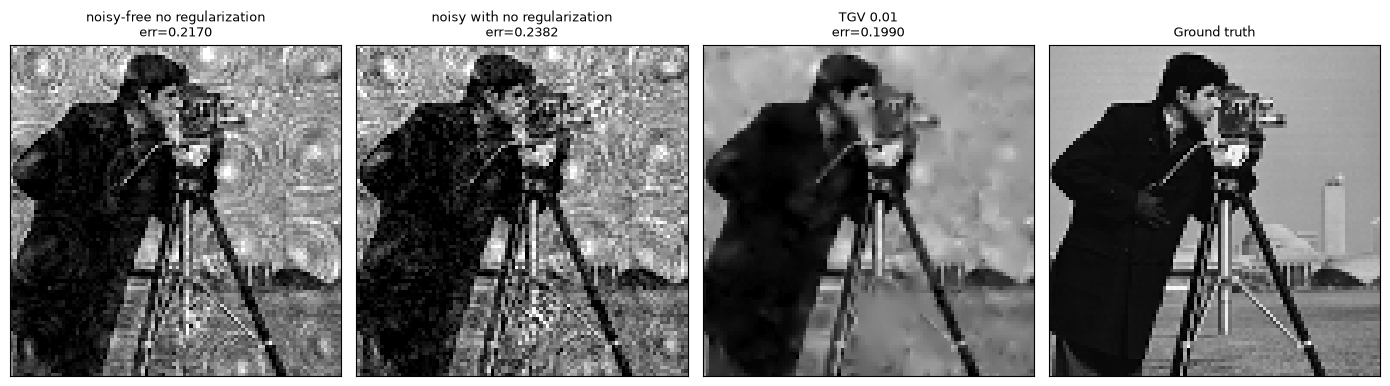

In [44]:
# ============ 噪声下 MSE vs MSE+TGV（固定 beta） ============
P0_REG_CROP = 48        # 中心 128（约等于照明区）；旧版 128 画布上的 16 已无意义
P0_PEAK_PHOTONS = 1e3
P0_STAGES = 8
P0_SEED = 2026
P0_BETA = 1e-2
P0_TGV_W1, P0_TGV_W2 = 1.0, 2.0

REG_CROP = P0_REG_CROP
_c = EVAL_CROP          # 指标一律用评估区，不要跟正则区混用（见 plan_baseline_AD §E3）
_tgv = ic.make_tgv_loss(w1=P0_TGV_W1, w2=P0_TGV_W2, reduce='mean')


def _err(o):
    r, g = o[_c:-_c, _c:-_c], obj[_c:-_c, _c:-_c]
    r_al, _ = ic.align_global_factor(r, g)
    return float(np.linalg.norm(r_al - g)/np.linalg.norm(g))


_clean = input2.copy()
_scale = P0_PEAK_PHOTONS/float(_clean.max())
_noisy = (np.random.default_rng(P0_SEED)
          .poisson(np.maximum(_clean, 0)*_scale).astype(np.float32)/_scale)
_amp_err = (np.linalg.norm(np.sqrt(_noisy) - np.sqrt(_clean)) /
            np.linalg.norm(np.sqrt(_clean)))
print(f'剂量 PEAK_PHOTONS={P0_PEAK_PHOTONS:g}  平均 {_clean.mean()*_scale:.1f} 光子/px')
print(f'  幅值相对误差 {_amp_err:.1%}   零像素 {100*(_noisy == 0).mean():.0f}%'
      f'   REG_CROP={REG_CROP}  stages={P0_STAGES}  TGV beta={P0_BETA:g}')

res = {}
try:
    print('\n[1/3] 无噪声 无正则')
    tf.keras.backend.clear_session()
    m = Ptycho(); ro, rp = m.train(P0_STAGES, tv1=0.0, tv2=0.0, verbose=0)
    res['noisy-free no regularization'] = (_err(get_object(m.OBJ)), ro, rp, get_object(m.OBJ))

    input2 = _noisy

    print('[2/3] 有噪声 无正则')
    tf.keras.backend.clear_session()
    m = Ptycho(); ro, rp = m.train(P0_STAGES, tv1=0.0, tv2=0.0, verbose=0)
    res['noisy with no regularization'] = (_err(get_object(m.OBJ)), ro, rp, get_object(m.OBJ))

    print(f'[3/3] 有噪声 TGV beta={P0_BETA:g}')
    tf.keras.backend.clear_session()
    m = Ptycho()
    ro, rp = m.train(P0_STAGES, tv1=P0_BETA, tv2=0.0,
                     verbose=0, reg_loss=_tgv)
    res[f'TGV {P0_BETA:g}'] = (_err(get_object(m.OBJ)), ro, rp, get_object(m.OBJ))
finally:
    input2 = _clean
    print('(input2 已恢复无噪声)')

print('\n' + '='*70)
print(f'{"配置":<16s}{"复场误差":>11s}{"SSIM":>9s}{"PSNR(dB)":>11s}{"探针误差":>11s}')
print('-'*70)
for t, (e, ro, rp, _o) in res.items():
    print(f'{t:<16s}{e:11.4f}{ro["ssim_o_amp"][-1]:9.4f}'
          f'{ro["psnr_o_amp"][-1]:11.2f}{rp["relerr_p_complex"][-1]:11.4f}')
print('='*70)

_base = res['noisy with no regularization'][0]
_clean_e = res['noisy-free no regularization'][0]
_tgv_key = f'TGV {P0_BETA:g}'
_tgv_e = res[_tgv_key][0]
print(f'\n噪声的代价:  {_clean_e:.4f} -> {_base:.4f}   (+{_base-_clean_e:.4f})')
print(f'TGV beta={P0_BETA:g}:  {_base:.4f} -> {_tgv_e:.4f}   '
      f'({_tgv_e-_base:+.4f})  -> {"有帮助" if _tgv_e < _base else "没帮助"}')
if _tgv_e < _base:
    print(f'  挽回了噪声代价的 {100*(_base-_tgv_e)/(_base-_clean_e):.0f}%')
else:
    print('  -> 该剂量下 TGV 无正收益。可把 P0_PEAK_PHOTONS 降到 1e2（幅值误差约27%）再试')

_gt = np.abs(obj)[_c:-_c, _c:-_c]
show = ['noisy-free no regularization', 'noisy with no regularization', _tgv_key]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, t in zip(axes, show):
    r, _ = ic.align_global_factor(res[t][3][_c:-_c, _c:-_c], obj[_c:-_c, _c:-_c])
    ax.imshow(np.abs(r), cmap='gray', vmin=_gt.min(), vmax=_gt.max())
    ax.set_title(f'{t}\nerr={res[t][0]:.4f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].imshow(_gt, cmap='gray'); axes[-1].set_title('Ground truth', fontsize=9)
axes[-1].set_xticks([]); axes[-1].set_yticks([])
fig.tight_layout(); plt.show()

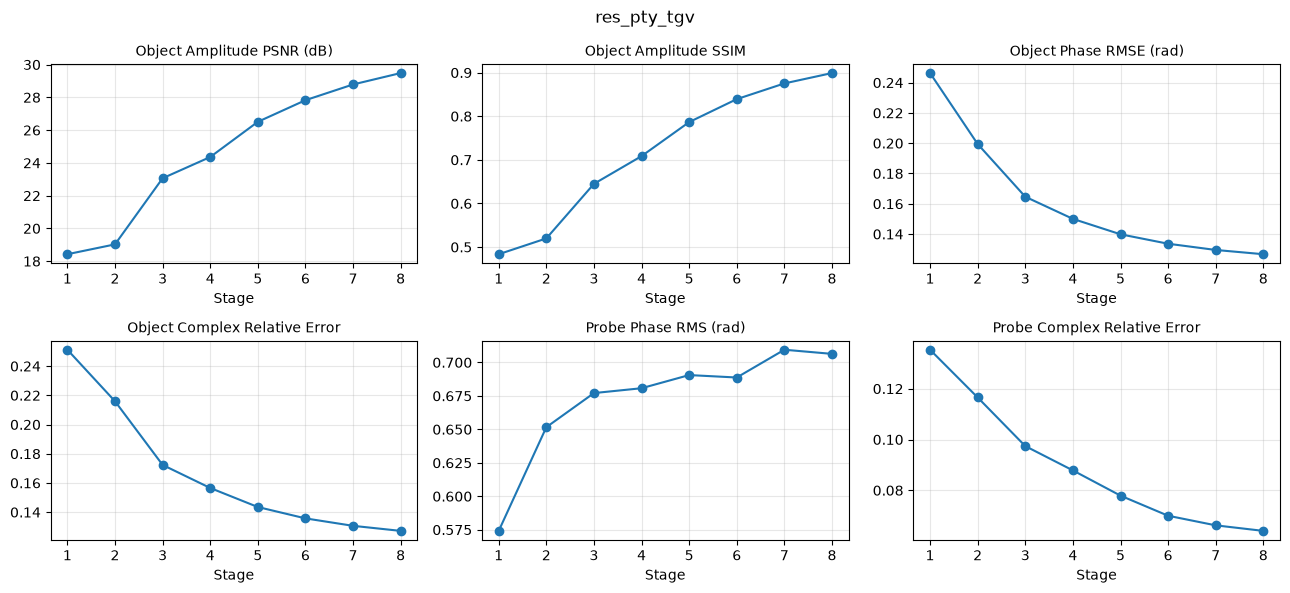

metric                       final
psnr_o_amp                 29.4841
ssim_o_amp                  0.8990
psnr_o_phi                 21.8042
ssim_o_phi                  0.6036
rmse_o_phi_rad              0.1267
relerr_o_complex            0.1272
rms_p_phi_rad               0.7064
relerr_p_complex            0.0640


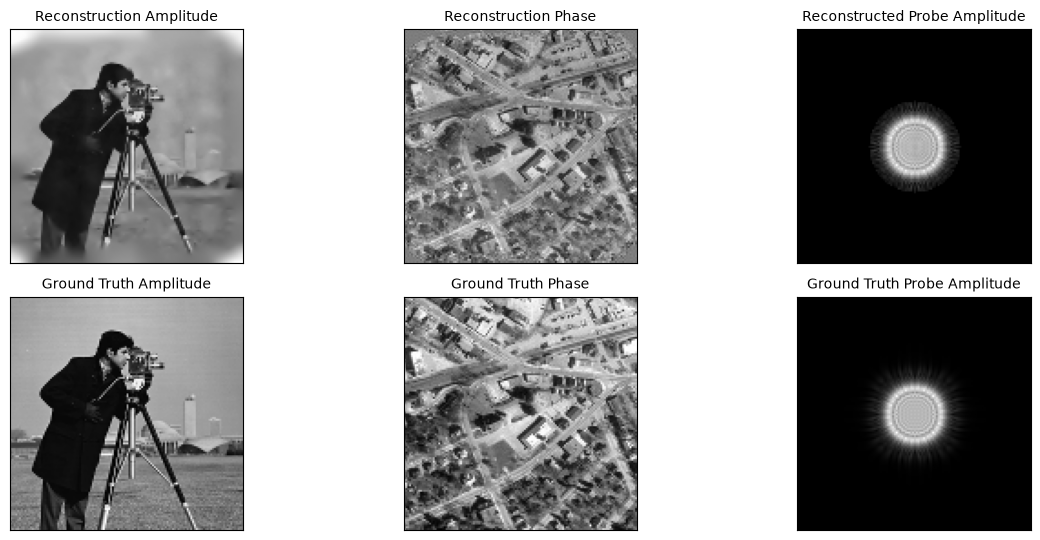

Probe complex relative error: 0.0640
(global complex factor removed - it is degenerate with the object's)


In [67]:
# ===================== Results =====================
ic.plot_records(record_obj, record_probe, title=run_name, plt=plt, lang='en')
ic.print_records(record_obj, record_probe, lang='en')

rec = get_object(pty.OBJ)
# 全局复因子必须在【评估区】里定，不能用整幅画布 —— 画布外围没有数据约束，
# 那里的垃圾值会把因子整个带偏。
_c0 = EVAL_CROP
_, _g = ic.align_global_factor(rec[_c0:-_c0, _c0:-_c0], obj[_c0:-_c0, _c0:-_c0])
rec_al = rec*_g
amp_r, phi_r = get_probe(pty.OBJ)

plt.figure(figsize=(13, 5.5))
for i, (im, t) in enumerate([
        (np.abs(rec_al), 'Reconstruction Amplitude'),
        (np.angle(rec_al), 'Reconstruction Phase'),
        (amp_r, 'Reconstructed Probe Amplitude'),
        (np.abs(obj), 'Ground Truth Amplitude'),
        (np.angle(obj), 'Ground Truth Phase'),
        (np.abs(probe), 'Ground Truth Probe Amplitude')]):
    plt.subplot(2, 3, i+1)
    plt.imshow(im, cmap='gray'); plt.title(t, fontsize=10)
    plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.show()

_m = support > 0
_pal, _ = ic.align_global_factor(amp_r*np.exp(1j*phi_r)*_m, probe*_m)
print(f'Probe complex relative error: '
      f'{np.linalg.norm(_pal-probe*_m)/np.linalg.norm(probe*_m):.4f}')
print('(global complex factor removed - it is degenerate with the object\'s)')